In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from btorch.models import environ, functional, glif, rnn, synapse
from btorch.models.linear import DenseConn

# ==========================================
# 1. 基础环境设置
# ==========================================
torch.set_default_dtype(torch.float32)
DEVICE = torch.device("cpu")
DTYPE = torch.float32

# ==========================================
# 2. 定义双神经元单向连接系统
# ==========================================
class TwoNeuronSystem(nn.Module):
    def __init__(self, device="cpu"):
        super().__init__()
        
        # 定义包含 2 个神经元的 GLIF 组
        self.neuron = glif.GLIF3(
            n_neuron=2,
            v_threshold=-45.0,
            v_reset=-60.0,
            c_m=2.0,
            tau=20.0,
            tau_ref=2.0,
            k=[0.1, 0.2],
            asc_amps=[1.0, -2.0],
            step_mode="s",
            backend="torch",
            device=device,
        )
        
        # 定义 2x2 的连接矩阵
        self.conn = DenseConn(2, 2, bias=None, device=device)
        
        # 清空所有默认的随机连接
        self.conn.weight.data.zero_()
        
        # 【关键】定向连接：让 0 号神经元连接到 1 号神经元
        # 权重矩阵 W 的形状是 (out_features, in_features)
        # 所以 W[1, 0] 代表 input=0, output=1 的突触权重
        self.conn.weight.data[1, 0] = 5.0 
        
        # 定义 Alpha 突触
        self.synapse = synapse.AlphaPSC(
            n_neuron=2,
            tau_syn=5.0,
            linear=self.conn,
            step_mode="s",
        )
        
        # 组装为支持多时间步的 RNN 系统
        self.brain = rnn.RecurrentNN(
            neuron=self.neuron,
            synapse=self.synapse,
            step_mode="m",
            update_state_names=("neuron.v", "synapse.psc"),
        )

    def forward(self, x):
        spike, states = self.brain(x)
        return spike, states

model = TwoNeuronSystem(device=str(DEVICE)).to(device=DEVICE, dtype=DTYPE)

In [11]:
# ==========================================
# 3. 仿真数据准备与模型初始化
# ==========================================
T = 100               # 仿真时间 100 ms
I_values = [1.0, 1.6, 3.0] # 三种不同的输入电流大小
batch_size = len(I_values)

# 构造输入矩阵: shape = (Time, Batch, Neuron_Num)
inputs = torch.zeros((T, batch_size, 1), device=DEVICE, dtype=DTYPE)
for b, I in enumerate(I_values):
    inputs[:, b, 0] = I  # 为不同的 Batch 注入不同的恒定电流

# btorch 状态初始化与重置
functional.init_net_state(model, batch_size=batch_size, device=str(DEVICE))
functional.reset_net(model, batch_size=batch_size)

# 处理 btorch 中可能出现的 float64 buffer 类型偏移
def _cast_all_floating_buffers_(module: nn.Module, dtype: torch.dtype, device: torch.device):
    for buffer_name, buffer in list(module.named_buffers()):
        if buffer is not None and torch.is_floating_point(buffer):
            casted = buffer.to(device=device, dtype=dtype)
            parts = buffer_name.split(".")
            target = module
            for p in parts[:-1]: target = getattr(target, p)
            setattr(target, parts[-1], casted)
_cast_all_floating_buffers_(model, DTYPE, DEVICE)

# ==========================================
# 4. 执行仿真
# ==========================================
with environ.context(dt=1.0):
    _, states = model(inputs)

# 提取状态轨迹并转为 numpy 数组用于绘图
# states["neuron.v"] shape: (T, Batch, 1) -> (T, Batch)
v_traces = states["neuron.v"][:, :, 0].detach().cpu().numpy()     
psc_traces = states["synapse.psc"][:, :, 0].detach().cpu().numpy() 
time_axis = range(T)

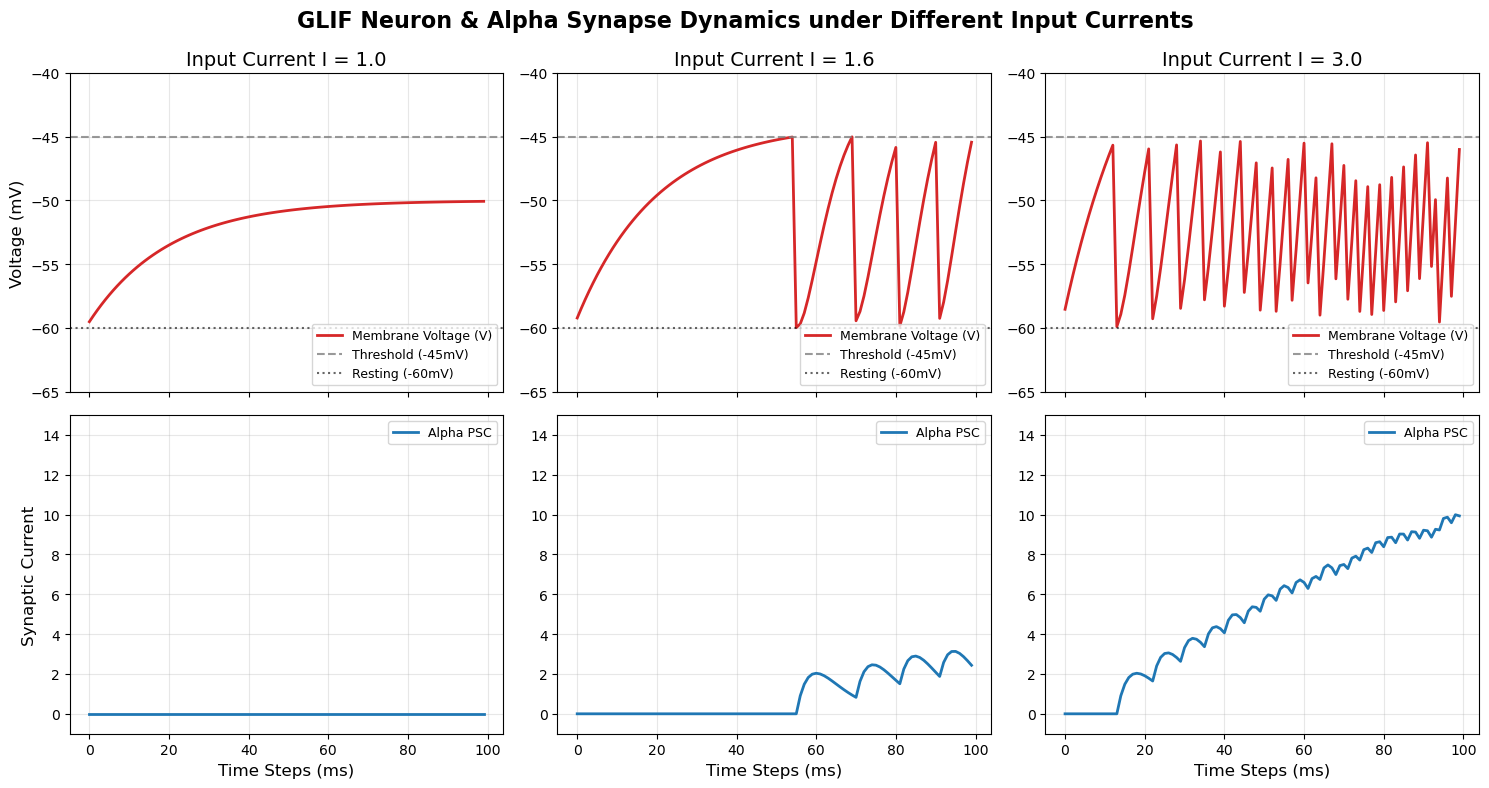

In [12]:
# ==========================================
# 5. 结果可视化
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle("GLIF Neuron & Alpha Synapse Dynamics under Different Input Currents", fontsize=16, fontweight='bold')

for i, I in enumerate(I_values):
    # 第一行：膜电位 (Voltage) 轨迹
    ax_v = axes[0, i]
    ax_v.plot(time_axis, v_traces[:, i], color='#D62728', linewidth=2, label='Membrane Voltage (V)')
    
    # 绘制参考线 (阈值和静息电位)
    ax_v.axhline(-45.0, color='gray', linestyle='--', alpha=0.8, label='Threshold (-45mV)')
    ax_v.axhline(-60.0, color='black', linestyle=':', alpha=0.6, label='Resting (-60mV)')
    
    ax_v.set_title(f'Input Current I = {I}', fontsize=14)
    if i == 0: ax_v.set_ylabel('Voltage (mV)', fontsize=12)
    ax_v.legend(loc='lower right', fontsize=9)
    ax_v.grid(True, alpha=0.3)
    ax_v.set_ylim(-65, -40) # 固定 Y 轴范围方便对比

    # 第二行：突触后电流 (PSC) 轨迹
    ax_psc = axes[1, i]
    ax_psc.plot(time_axis, psc_traces[:, i], color='#1F77B4', linewidth=2, label='Alpha PSC')
    
    ax_psc.set_xlabel('Time Steps (ms)', fontsize=12)
    if i == 0: ax_psc.set_ylabel('Synaptic Current', fontsize=12)
    ax_psc.legend(loc='upper right', fontsize=9)
    ax_psc.grid(True, alpha=0.3)
    ax_psc.set_ylim(-1, 15) # 固定 Y 轴范围方便对比

plt.tight_layout()
plt.subplots_adjust(top=0.9) # 给主标题留出空间
plt.show()